> **Business Context:** Rossmann operates 3,000+ drug stores across 7 European countries. Accurate demand forecasting enables better stock management, reduces waste, and maximises revenue. This EDA investigates the key drivers of daily store sales.

## 1. Environment Setup & Imports

We begin by importing all necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns


<a id='2'></a>
## 2. Data Loading & Initial Inspection

We load the dataset, parse the `Date` column, and perform an initial sanity check on shape, column names, and data types.

In [2]:
df = pd.read_csv('data/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [3]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [4]:
DATA_PATH = 'data/train.csv'

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['Date'],
    dtype={'StateHoliday': str},
    low_memory=False
)

# Normalise StateHoliday: collapse integer 0 → string '0'
df['StateHoliday'] = df['StateHoliday'].astype(str).str.strip()


In [9]:
print("Dataset loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Dataset loaded
  Rows    : 1,017,209
  Columns : 9
  Memory  : 124.1 MB
Duplicate rows: 0


In [14]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [7]:
# Data types
print("Column data types:")
print(df.dtypes)

Column data types:
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object


In [8]:
print("Date range:")
print(f"  From : {df['Date'].min().date()}")
print(f"  To   : {df['Date'].max().date()}")
print(f"  Span : {(df['Date'].max() - df['Date'].min()).days} days")
print()
print(f"  Unique stores : {df['Store'].nunique()}")

Date range:
  From : 2013-01-01
  To   : 2015-07-31
  Span : 941 days

  Unique stores : 1115


In [11]:
# Statistical summary
df.describe(include='all').T.round(2)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,4,0,986159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056


<a id='3'></a>
## 3. Data Quality Assessment

### 3.1 Missing Values

In [14]:
# Missing values 
missing = df.isnull().sum().rename('Missing Count')
missing_pct = (df.isnull().mean() * 100).rename('Missing %')
missing_df = pd.concat([missing, missing_pct], axis=1)

print("Missing value report:")
print(missing_df.to_string())

Missing value report:
               Missing Count  Missing %
Store                      0        0.0
DayOfWeek                  0        0.0
Date                       0        0.0
Sales                      0        0.0
Customers                  0        0.0
Open                       0        0.0
Promo                      0        0.0
StateHoliday               0        0.0
SchoolHoliday              0        0.0


### 3.2 Duplicate Rows

In [16]:
# Duplicates
dup_count = df.duplicated().sum()

# Logical duplicates: same store on same date
dup_store_date = df.duplicated(subset=['Store', 'Date']).sum()

print(f"Fully duplicate rows  : {dup_count}")
print(f"Store-Date duplicates : {dup_store_date}")
print()

if dup_count == 0:
    print("No duplicate rows found.")
else:
    print("Duplicate rows exist, need to handle them.")

Fully duplicate rows  : 0
Store-Date duplicates : 0

No duplicate rows found.


### 3.3 Unique Values per Column

In [18]:
# Cardinality 
cardinality = df.nunique()

print("Unique values per column:")
print(cardinality)

Unique values per column:
Store             1115
DayOfWeek            7
Date               942
Sales            21734
Customers         4086
Open                 2
Promo                2
StateHoliday         4
SchoolHoliday        2
dtype: int64


<a id='4'></a>
## 4. Distribution of Sales

Understanding the statistical distribution of the target variable (`Sales`) is the most critical first step in demand forecasting. Skewness, outliers and multi-modality directly influence model choice and feature engineering strategies.

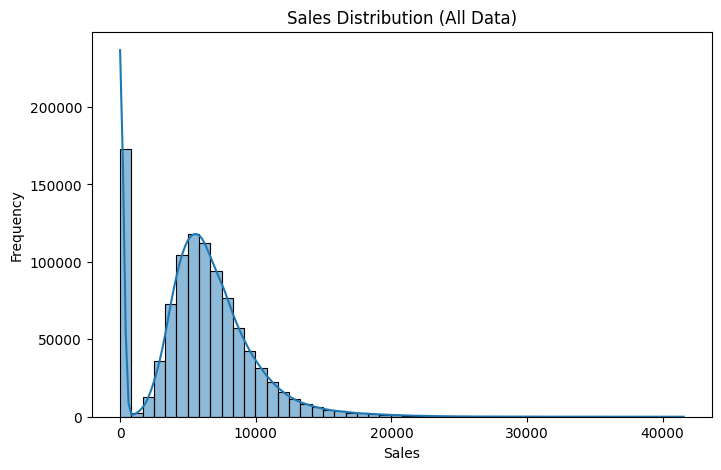

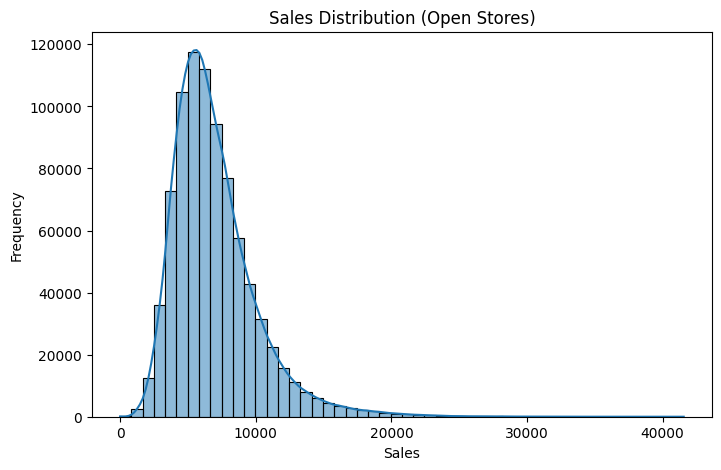

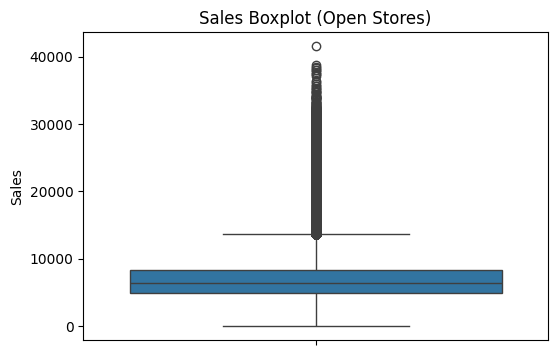

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [19]:
df_open = df[df['Open'] == 1]

# 4a: Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Sales Distribution (All Data)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# 4b: Open Stores Distribution
plt.figure(figsize=(8,5))
sns.histplot(df_open['Sales'], bins=50, kde=True)
plt.title("Sales Distribution (Open Stores)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# 4c: Box plot ---
plt.figure(figsize=(6,4))
sns.boxplot(y=df_open['Sales'])
plt.title("Sales Boxplot (Open Stores)")
plt.show()


# Summary statistics
df_open['Sales'].describe()

<a id='5'></a>
## 5. Relationship Between Sales and Customers

`Customers` is the number of shoppers per day. Its relationship with `Sales` reveals average basket size and whether footfall or spend-per-visit is the primary revenue driver.

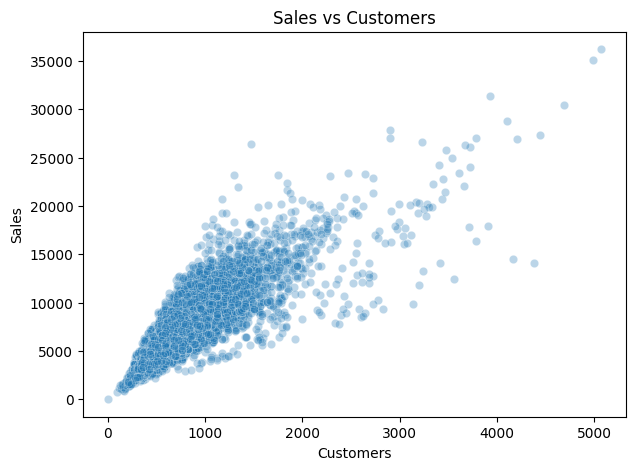

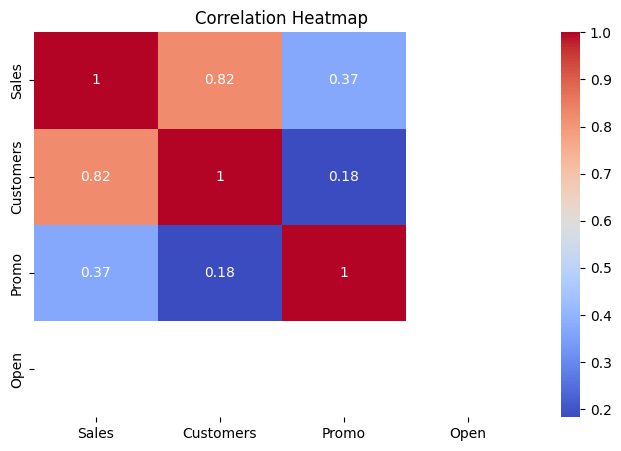

Correlation between Sales and Customers: 0.824


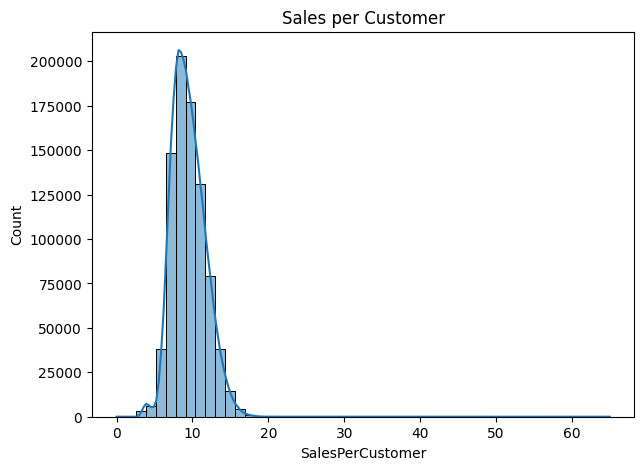

Average Sales per Customer: 9.49


In [24]:
# Scatter
sample = df_open.sample(10000, random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(x='Customers', y='Sales', data=sample, alpha=0.3)
plt.title("Sales vs Customers")
plt.show()

# Correlation
plt.figure(figsize=(8,5))
sns.heatmap(df_open[['Sales', 'Customers', 'Promo', 'Open']].corr(), 
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

corr = df_open[['Sales', 'Customers']].corr().iloc[0,1]
print("Correlation between Sales and Customers:", round(corr, 3))


df_open = df_open[df_open['Customers'] > 0]
df_open['SalesPerCustomer'] = df_open['Sales'] / df_open['Customers']

# Distribution
plt.figure(figsize=(7,5))
sns.histplot(df_open['SalesPerCustomer'], bins=50, kde=True)
plt.title("Sales per Customer")
plt.show()

# Average
print("Average Sales per Customer:", round(df_open['SalesPerCustomer'].mean(), 2))

<a id='6'></a>
## 6. Sales per Store

Store-level heterogeneity is a key challenge in demand forecasting. Stores may differ in size, location type, assortment, and local competition. We quantify this variability here.

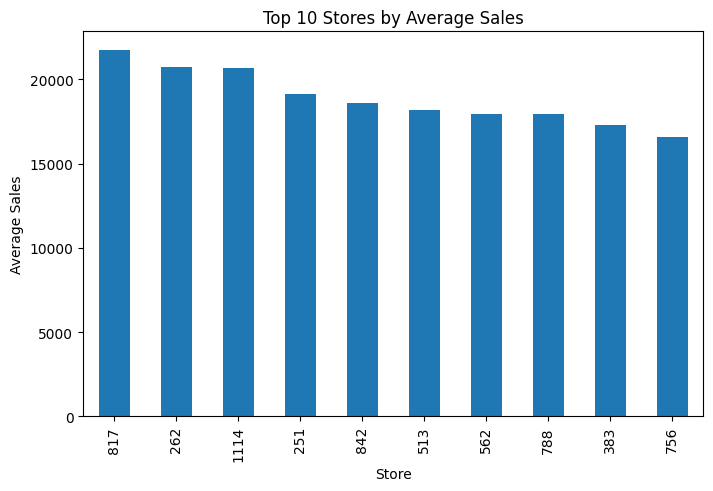

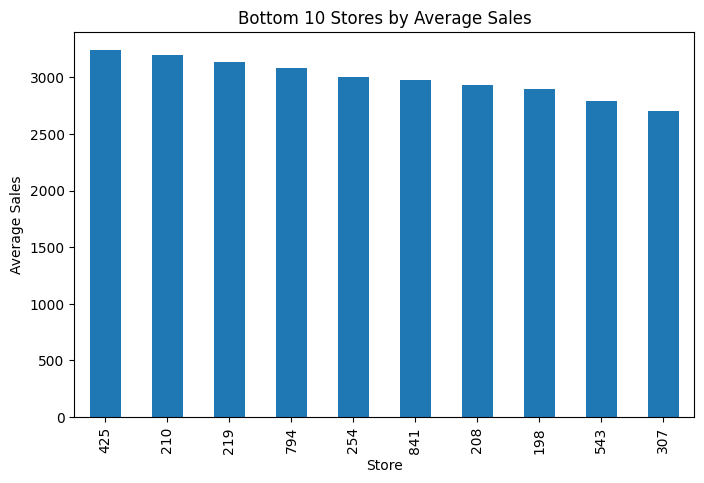

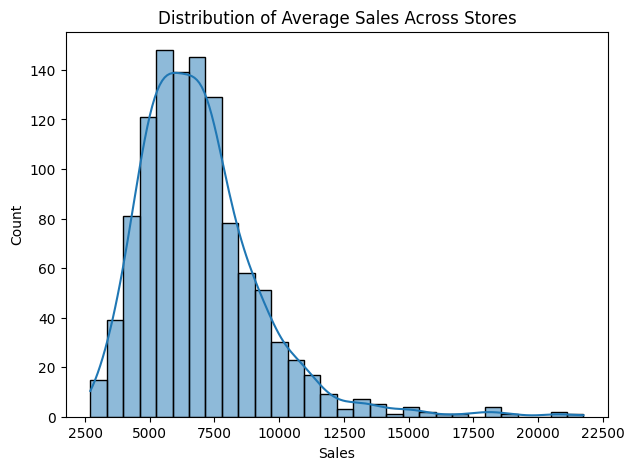

Highest sales store: 817
Lowest sales store: 307


In [30]:
# Average sales per store
store_sales = df_open.groupby('Store')['Sales'].mean().sort_values(ascending=False)

# Top 10 stores
top_stores = store_sales.head(10)

plt.figure(figsize=(8,5))
top_stores.plot(kind='bar')
plt.title("Top 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.show()

# Bottom 10 stores
bottom_stores = store_sales.tail(10)

plt.figure(figsize=(8,5))
bottom_stores.plot(kind='bar')
plt.title("Bottom 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.show()

# Distribution of store sales
plt.figure(figsize=(7,5))
sns.histplot(store_sales, bins=30, kde=True)
plt.title("Distribution of Average Sales Across Stores")
plt.show()

# Simple summary
print("Highest sales store:", store_sales.idxmax())
print("Lowest sales store:", store_sales.idxmin())

<a id='8'></a>
## 7. Time-Series & Trend Analysis

Trend analysis at daily, monthly and yearly granularity helps identify long-term growth or decline patterns, which are essential for forecasting model selection.

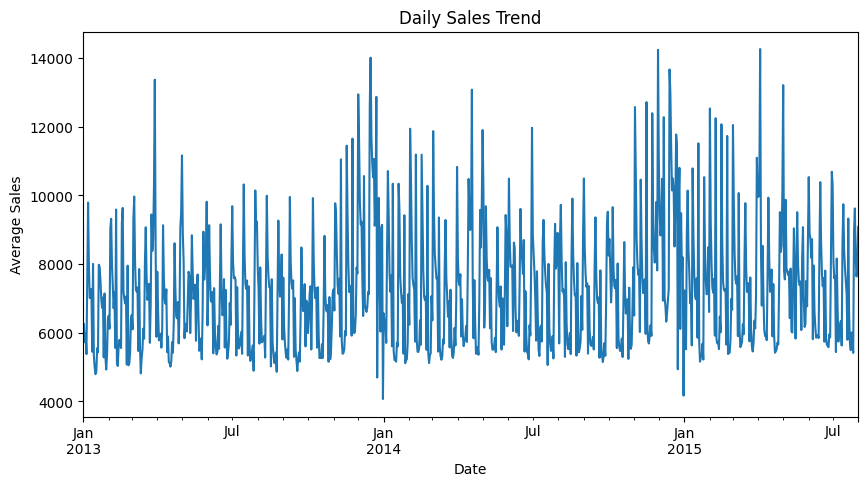

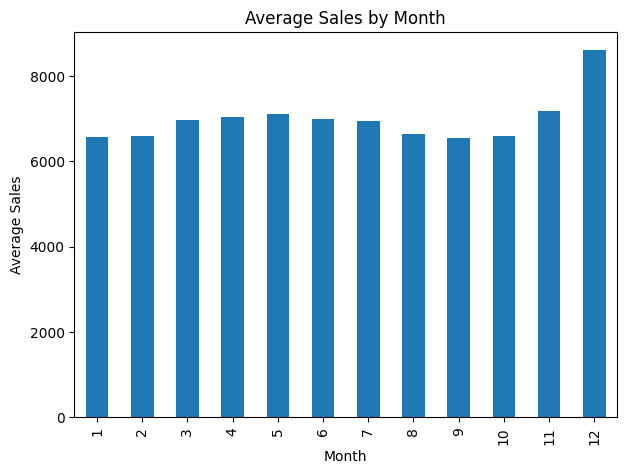

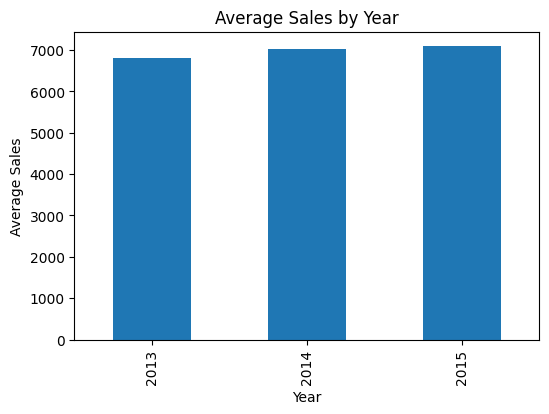

Yearly Average Sales:
Year
2013    6814.755002
2014    7026.105868
2015    7088.235123
Name: Sales, dtype: float64


In [26]:
# Feature engineering 

# Extract basic time features
df_open['Year'] = df_open['Date'].dt.year
df_open['Month'] = df_open['Date'].dt.month

# Daily trend
daily = df_open.groupby('Date')['Sales'].mean()

plt.figure(figsize=(10,5))
daily.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.show()

# Monthly trend
monthly = df_open.groupby('Month')['Sales'].mean()

plt.figure(figsize=(7,5))
monthly.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

# Yearly trend
yearly = df_open.groupby('Year')['Sales'].mean()

plt.figure(figsize=(6,4))
yearly.plot(kind='bar')
plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

# Print yearly values
print("Yearly Average Sales:")
print(yearly)

<a id='9'></a>
## 8. Seasonality Patterns

Retail seasonality operates at multiple frequencies — **monthly**, **weekly**, and even **day-of-month** effects. We decompose each here.

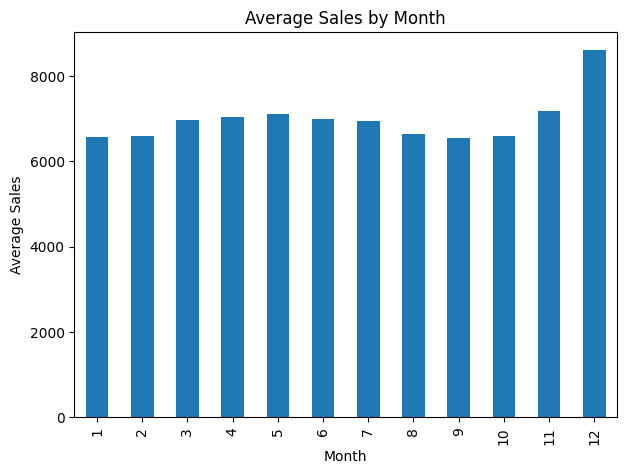

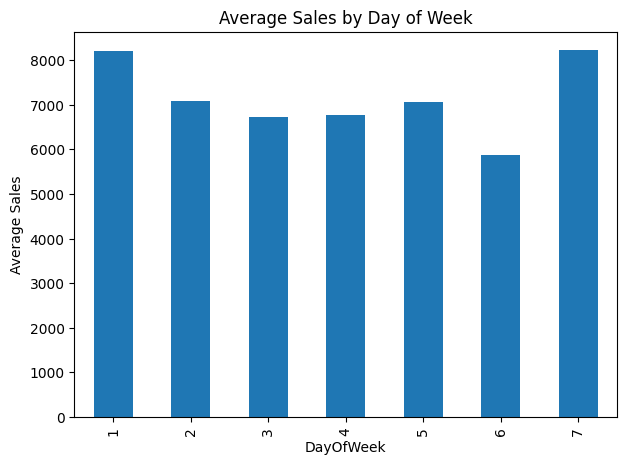

Monthly Sales:
Month
1     6564.298651
2     6589.494012
3     6976.817749
4     7046.487067
5     7106.808038
6     7001.402127
7     6953.575827
8     6649.229053
9     6547.469104
10    6602.967255
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64

DayOfWeek Sales:
DayOfWeek
1    8216.252259
2    7088.359846
3    6728.786679
4    6768.164700
5    7073.034133
6    5875.084935
7    8224.723908
Name: Sales, dtype: float64


In [28]:
# Seasonality Analysis

# Monthly seasonality
monthly_avg = df_open.groupby('Month')['Sales'].mean()

plt.figure(figsize=(7,5))
monthly_avg.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

# Day of week seasonality
weekly_avg = df_open.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(7,5))
weekly_avg.plot(kind='bar')
plt.title("Average Sales by Day of Week")
plt.xlabel("DayOfWeek")
plt.ylabel("Average Sales")
plt.show()

# Print values
print("Monthly Sales:")
print(monthly_avg)

print("\nDayOfWeek Sales:")
print(weekly_avg)

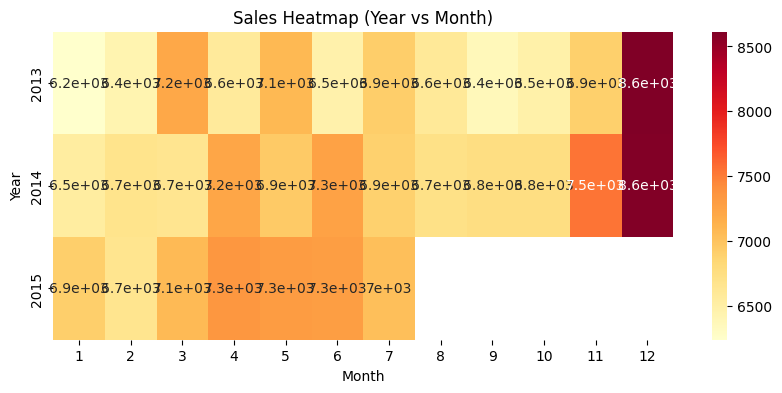

In [29]:
# Heatmap: Year vs Month

pivot = df_open.pivot_table(values='Sales', index='Year', columns='Month', aggfunc='mean')

plt.figure(figsize=(10,4))
sns.heatmap(pivot, annot=True, cmap='YlOrRd')

plt.title("Sales Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()